<a href="https://colab.research.google.com/github/RekhaThota22/BigMart-Regression/blob/main/Spotify.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
#11:11 am

In [27]:
# Importing libraries:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [28]:
# Loading the dta
df = pd.read_csv('/content/spotify.csv')

In [29]:
df.head()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,liked
0,0.803,0.6240,7,-6.764,0,0.0477,0.451,0.000734,0.1000,0.6280,95.968,304524,4,0
1,0.762,0.7030,10,-7.951,0,0.3060,0.206,0.000000,0.0912,0.5190,151.329,247178,4,1
2,0.261,0.0149,1,-27.528,1,0.0419,0.992,0.897000,0.1020,0.0382,75.296,286987,4,0
3,0.722,0.7360,3,-6.994,0,0.0585,0.431,0.000001,0.1230,0.5820,89.860,208920,4,1
4,0.787,0.5720,1,-7.516,1,0.2220,0.145,0.000000,0.0753,0.6470,155.117,179413,4,1


In [30]:
df.columns

Index(['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'duration_ms', 'time_signature', 'liked'],
      dtype='object')

In [31]:
df.shape

(195, 14)

In [32]:
df.isnull().sum()


,0
danceability,0
energy,0
key,0
loudness,0
mode,0
speechiness,0
acousticness,0
instrumentalness,0
liveness,0
valence,0


In [33]:
# No nulls oberved.Moving to check duplicatges
df.duplicated().sum()


np.int64(0)

In [34]:
# NO duplicates also

In [35]:
# Though I couldnt evidently see the data columns with spaces still I would like to be sure about 1 thing ,
#that there arent any spaces or any char that would interrupt me from column name cols so cleansing it the standard way
#and also ill check for any invalid col values and replace them with nan
df.columns = df.columns.astype(str).str.strip().str.lower().str.replace(' ','_')

In [36]:
for col in df.columns:
   df[col].replace(['#','@','!','$','%','^','&','*','Null','N/A','NA','-','--'],np.nan,inplace = True)

/tmp/ipykernel_5539/198109613.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].replace(['#','@','!','$','%','^','&','*','Null','N/A','NA','-','--'],np.nan,inplace = True)


In [37]:
df.isnull().sum()

,0
danceability,0
energy,0
key,0
loudness,0
mode,0
speechiness,0
acousticness,0
instrumentalness,0
liveness,0
valence,0


In [39]:
# checking the info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   danceability      195 non-null    float64
 1   energy            195 non-null    float64
 2   key               195 non-null    int64  
 3   loudness          195 non-null    float64
 4   mode              195 non-null    int64  
 5   speechiness       195 non-null    float64
 6   acousticness      195 non-null    float64
 7   instrumentalness  195 non-null    float64
 8   liveness          195 non-null    float64
 9   valence           195 non-null    float64
 10  tempo             195 non-null    float64
 11  duration_ms       195 non-null    int64  
 12  time_signature    195 non-null    int64  
 13  liked             195 non-null    int64  
dtypes: float64(9), int64(5)
memory usage: 21.5 KB


In [40]:
# no conversion needed as the info clearly states all are numeric either float  or int as per alingned col values also ,we need numeric any way for model building
# Identyfying the target,here our target is 'liked'
# so checking the data balance
df['liked'].value_counts()

,count
liked,
1,100
0,95


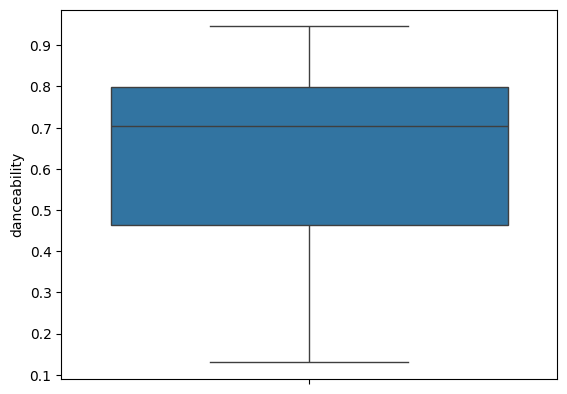

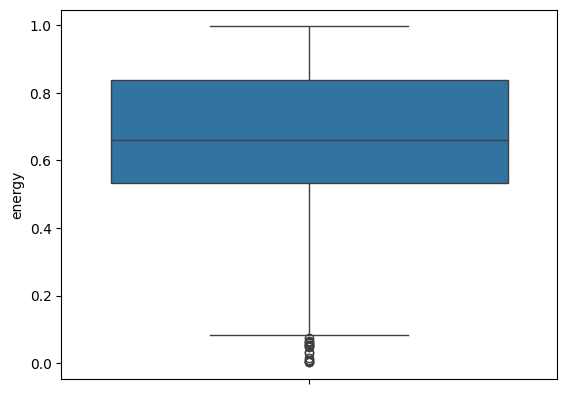

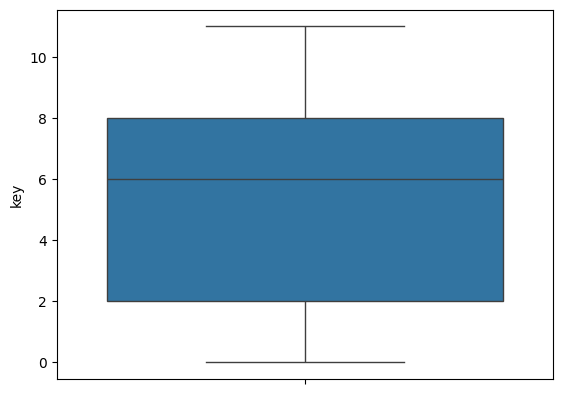

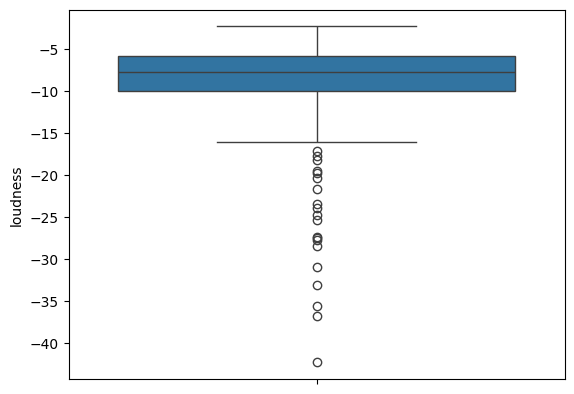

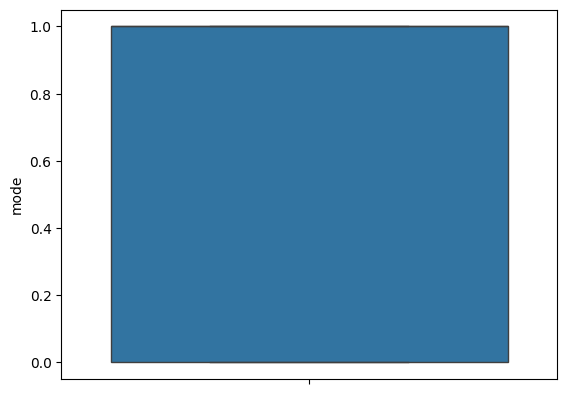

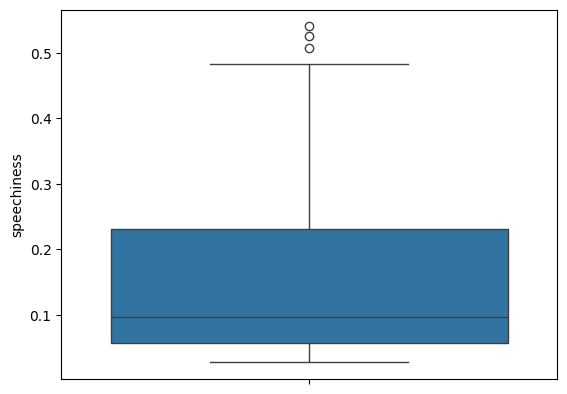

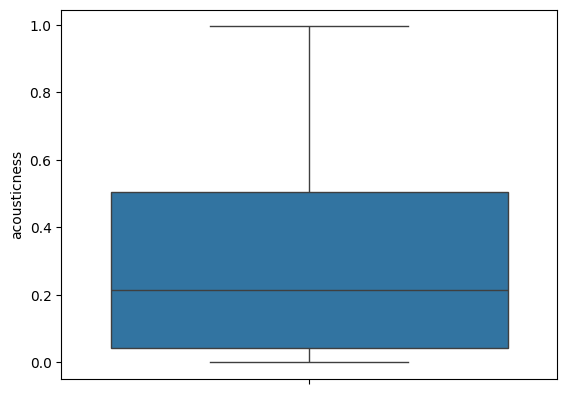

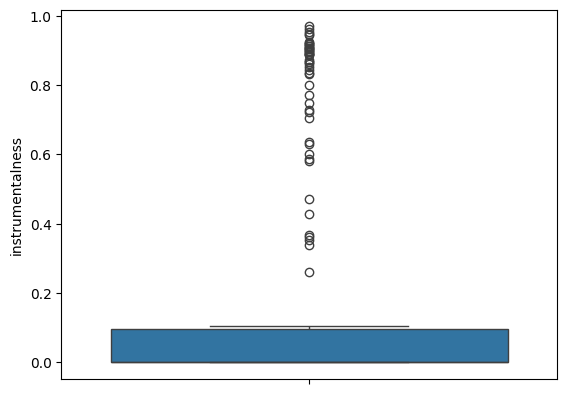

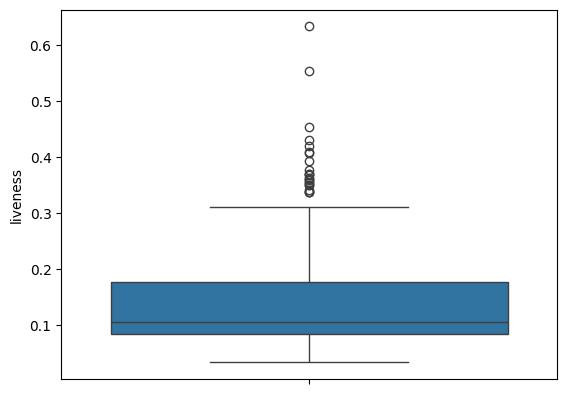

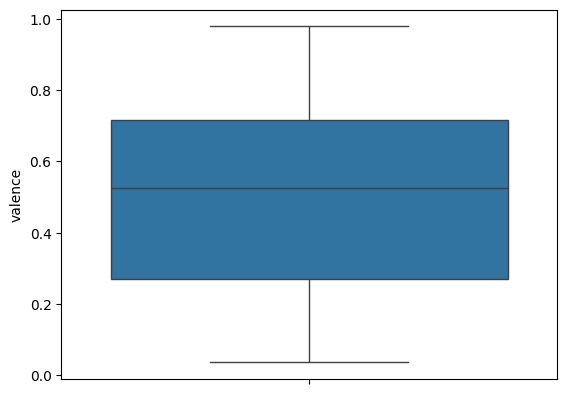

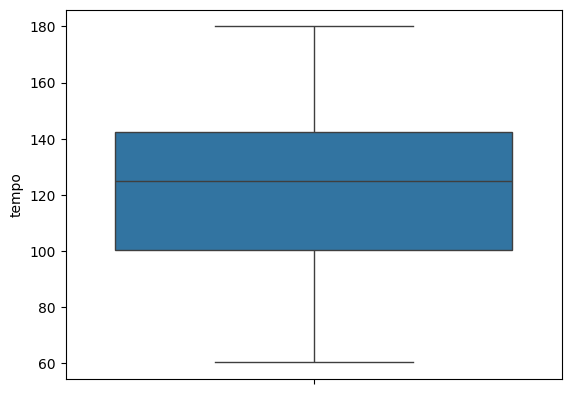

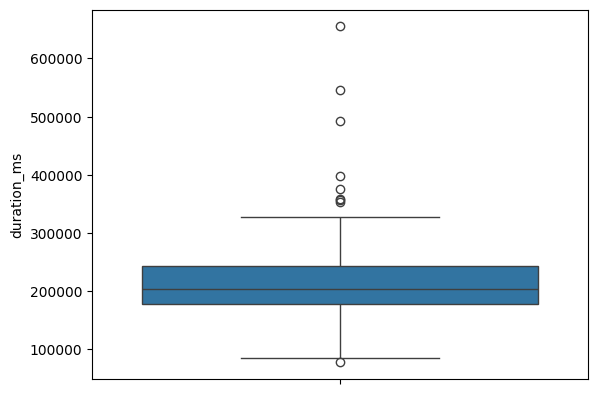

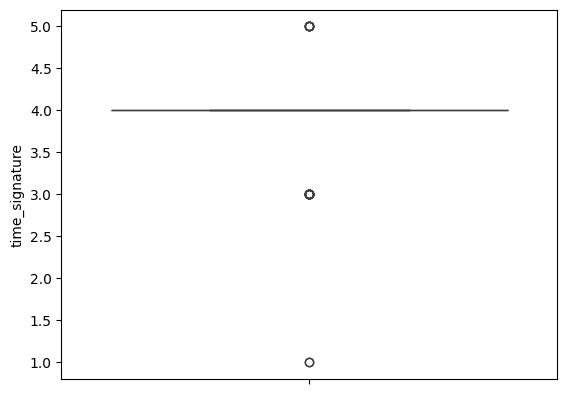

In [46]:
# We see the data is not much of a imbalance,so we will check for outliers
for col in df.drop('liked',axis = 1):
  sns.boxplot(df[col])
  plt.show()

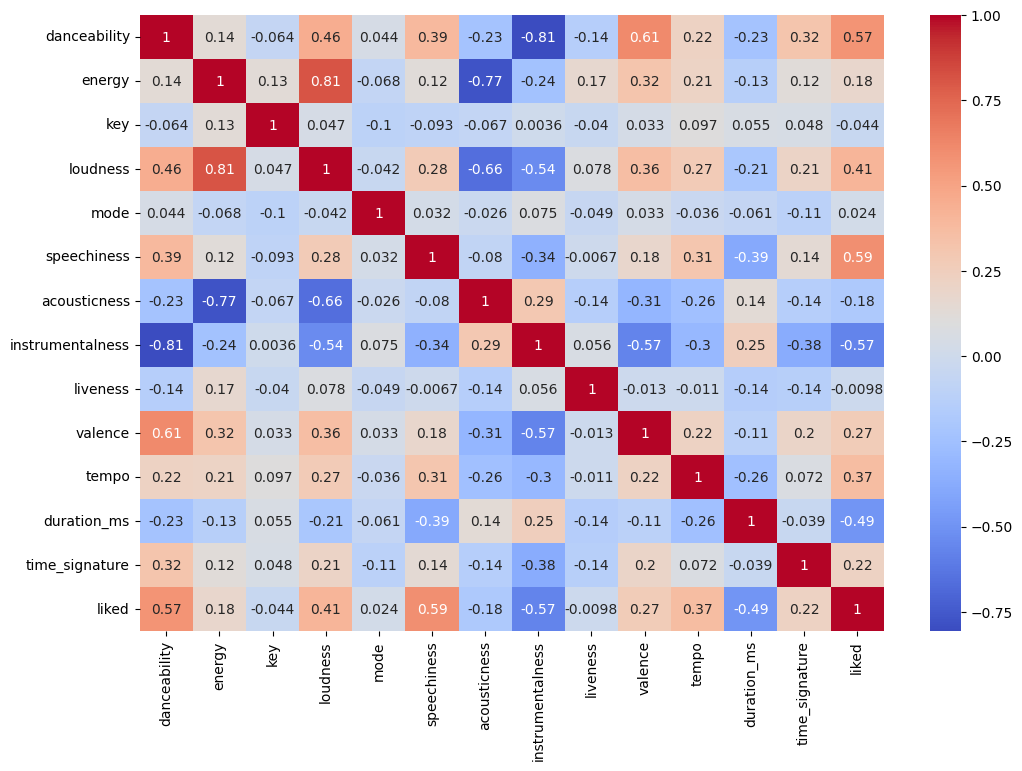

In [48]:
# The outliers are domain valid as music can be of different generes and diff styles so finding the outliers are reasonalble
# Checking the correlation
corr = df.corr()
plt.figure(figsize = (12,8))
sns.heatmap(corr,annot= True,cmap = 'coolwarm')
plt.show()


In [50]:
# strong Positive correlation(>0.5) observed in: energy vs loudness,likes vs dancebility,liked vs valence,liked vs loudness,speechiness vs liked,valence vs dancebility
# Strongest negative correlation(<-0.5) observed in :dancebility vs instrumentelness(-0.81),energy vs auousticness(-0.77),loudness vs instrumentalness(-0.54),lodness vs aucosticness(-0.66),dancebility vs instrumental ness(-0.81),valance vs instrumental ness(-0.57),instrumentalness vs liked
# multicollinearity : loudness vs energy(0.81) ,energy vs loudness = 0.81
# danceability vs instrumentalness = -0.81
# energy vs acousticness = -0.77

# Im gonna need features for tree modles so im not removing them directly I will remove after checking vif for logistic/egression models


In [57]:
# feature and Target seperation:
X = df.drop('liked',axis = 1)
y= df['liked']
X.shape,y.shape

((195, 13), (195,))

In [58]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size = 0.20,stratify = y)

In [61]:
#Scaling before model creation
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f'X_train.shape = {X_train.shape}')
print(f'X_test.shape = {X_test.shape}')
print(f'X_train_scaled.shape = {X_train_scaled.shape}')
print(f'X_test_scaled.shape = {X_test_scaled.shape}')


X_train.shape = (156, 13)
X_test.shape = (39, 13)
X_train_scaled.shape = (156, 13)
X_test_scaled.shape = (39, 13)


In [62]:
# Check if something went wrong of not the shape would allign the scaled data shape correctly
# Now as the target is a numerical column we use Logistic regression baseline
# Decision Tree
# Random Forest
# SVM
# optional PCA+Logistic comparison

In [69]:
# Implementing logistic Regressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

log_reg = LogisticRegression()
log_reg.fit(X_train_scaled,y_train)
y_pred = log_reg.predict(X_test_scaled)
print('=='*10 ,'Logistic Regressor Results','=='*10)
print(f'Accuracy : {accuracy_score(y_test,y_pred)}')
print('=='*30)
print(f'Classification_report :{classification_report(y_test,y_pred)}')
print('=='*30)
print(f'Confusion_Martrix : {confusion_matrix(y_test,y_pred)}')

==================== Logistic Regressor Results ====================
Accuracy : 0.9230769230769231
Classification_report :              precision    recall  f1-score   support

           0       0.94      0.89      0.92        19
           1       0.90      0.95      0.93        20

    accuracy                           0.92        39
   macro avg       0.92      0.92      0.92        39
weighted avg       0.92      0.92      0.92        39

Confusion_Martrix : [[17  2]
 [ 1 19]]


The results of Logistic Regression  are balanced as precision said 90 % of songs were liked and recall out of that model succesfully identified 95 % .

In [96]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_train,y_train)
y_pred = dt.predict(X_test)
print('=='*10 ,'Decision Tree Classifier Results','=='*10)
print(f'Accuracy : {accuracy_score(y_test,y_pred)}')
print('=='*30)
print(f'Classification_report :{classification_report(y_test,y_pred)}')
print('=='*30)
print(f'Confusion_Martrix : {confusion_matrix(y_test,y_pred)}')

==================== Decision Tree Classifier Results ====================
Accuracy : 0.8717948717948718
Classification_report :              precision    recall  f1-score   support

           0       0.85      0.89      0.87        19
           1       0.89      0.85      0.87        20

    accuracy                           0.87        39
   macro avg       0.87      0.87      0.87        39
weighted avg       0.87      0.87      0.87        39

Confusion_Martrix : [[17  2]
 [ 3 17]]


In [101]:
train_score = dt.score(X_train,y_train)
test_score = dt.score(X_test,y_test)
print(f'Train Score : {train_score}')
print(f'Test Score : {test_score}')


Train Score : 1.0
Test Score : 0.8717948717948718


In [103]:
# Decision tree with improvements
dt = DecisionTreeClassifier(
    max_depth = 4,
    min_samples_split = 10,
    min_samples_leaf = 5,
    random_state = 42
)
dt.fit(X_train,y_train)
y_pred = dt.predict(X_test)
print('=='*10 ,'Decision Tree Classifier Results','=='*10)
print(f'Accuracy : {accuracy_score(y_test,y_pred)}')
print('=='*30)
print(f'Classification_report :{classification_report(y_test,y_pred)}')
print('=='*30)
print(f'Confusion_Martrix : {confusion_matrix(y_test,y_pred)}')

==================== Decision Tree Classifier Results ====================
Accuracy : 0.8974358974358975
Classification_report :              precision    recall  f1-score   support

           0       0.94      0.84      0.89        19
           1       0.86      0.95      0.90        20

    accuracy                           0.90        39
   macro avg       0.90      0.90      0.90        39
weighted avg       0.90      0.90      0.90        39

Confusion_Martrix : [[16  3]
 [ 1 19]]


In [104]:
# After tuning the score :
train_score = dt.score(X_train,y_train)
test_score = dt.score(X_test,y_test)
print(f'Train Score : {train_score}')
print(f'Test Score : {test_score}')


Train Score : 0.9423076923076923
Test Score : 0.8974358974358975


In [110]:
# Performance of RandomTreeClassifier is below:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators = 100,
    min_samples_split = 10,
    max_depth = 4,
    random_state = 42
)
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
print('=='*10 ,'Random Forest Classifier Results','=='*10)
print(f'Accuracy : {accuracy_score(y_test,y_pred)}')
print('=='*30)
print(f'Classification_report :{classification_report(y_test,y_pred)}')
print('=='*30)
print(f'Confusion_Martrix : {confusion_matrix(y_test,y_pred)}')

==================== Random Forest Classifier Results ====================
Accuracy : 0.9230769230769231
Classification_report :              precision    recall  f1-score   support

           0       0.94      0.89      0.92        19
           1       0.90      0.95      0.93        20

    accuracy                           0.92        39
   macro avg       0.92      0.92      0.92        39
weighted avg       0.92      0.92      0.92        39

Confusion_Martrix : [[17  2]
 [ 1 19]]


In [111]:
# Random Forest score :
train_score = rf.score(X_train,y_train)
test_score = rf.score(X_test,y_test)
print(f'Train Score : {train_score}')
print(f'Test Score : {test_score}')


Train Score : 0.9743589743589743
Test Score : 0.9230769230769231


In [123]:
# Performing SVM model:
from sklearn.svm import SVC
svc = SVC(kernel = 'rbf')
svc.fit(X_train_scaled,y_train)
y_pred = svc.predict(X_test_scaled)
print('=='*10 ,'SVM Classifier Results','=='*10)
print(f'Accuracy : {accuracy_score(y_test,y_pred)}')
print('=='*30)
print(f'Classification_report :{classification_report(y_test,y_pred)}')
print('=='*30)
print(f'Confusion_Martrix : {confusion_matrix(y_test,y_pred)}')

==================== SVM Classifier Results ====================
Accuracy : 0.9230769230769231
Classification_report :              precision    recall  f1-score   support

           0       0.90      0.95      0.92        19
           1       0.95      0.90      0.92        20

    accuracy                           0.92        39
   macro avg       0.92      0.92      0.92        39
weighted avg       0.92      0.92      0.92        39

Confusion_Martrix : [[18  1]
 [ 2 18]]


In [130]:
# Feature importance :
feature_importance = pd.DataFrame({
    'Feature' : X.columns,
    'Importances' : rf.feature_importances_
})
feature_importance = feature_importance.sort_values(by = 'Importances',ascending = False)

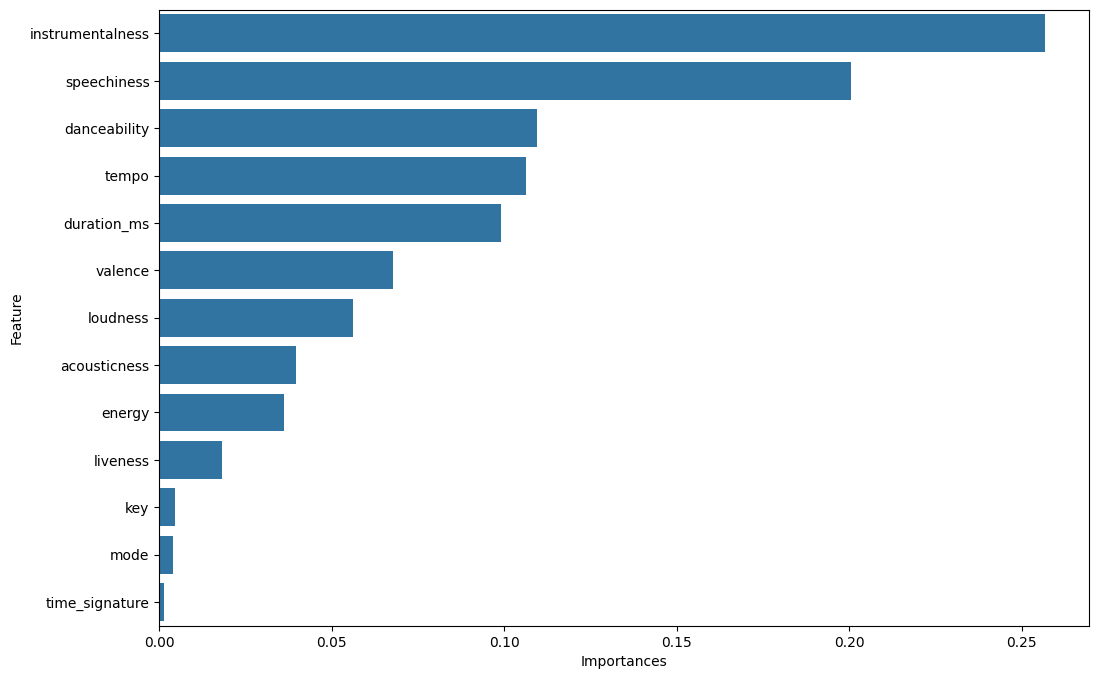

In [131]:
# plotting the featue importances
plt.figure(figsize = (12,8))
sns.barplot(x = 'Importances',y = 'Feature',data = feature_importance)
plt.show()

**RandomForest classifier** suggests instrumentalness,speechiness and dancebility are the strong predictors of whether a song is liked

In [134]:
# now using xgbclassifier
from xgboost import XGBClassifier
xgb = XGBClassifier(
    n_estimators = 100,
    learning_rate = 0.01,
    max_depth = 4,
    random_state = 42,
    eval_metric = 'logloss'
)
xgb.fit(X_train,y_train)
y_pred_xgb = xgb.predict(X_test)
print('=='*10 ,'XGB Classifier Results','=='*10)
print(f'Accuracy : {accuracy_score(y_test,y_pred_xgb)}')
print('=='*30)
print(f'Classification_report :{classification_report(y_test,y_pred_xgb)}')
print('=='*30)
print(f'Confusion_Martrix : {confusion_matrix(y_test,y_pred_xgb)}')


==================== XGB Classifier Results ====================
Accuracy : 0.9230769230769231
Classification_report :              precision    recall  f1-score   support

           0       0.94      0.89      0.92        19
           1       0.90      0.95      0.93        20

    accuracy                           0.92        39
   macro avg       0.92      0.92      0.92        39
weighted avg       0.92      0.92      0.92        39

Confusion_Martrix : [[17  2]
 [ 1 19]]


As we see , all the top ml models like DecisonTree,Random Forest ,XGBoost are aproximately delivering same results as that of logistic regression.This is likeluy because of the data set which is very small and there is not much of imbalance.et us now check and c]see what are the results with cross validation where we split the dat into 5 parts and see if we just got lucky or the cv says otherwise.

In [138]:
# validating logistic regression first:
from sklearn.model_selection import cross_val_score
log_reg = LogisticRegression()
cv_score = cross_val_score(
    log_reg,
    X_train_scaled,
    y_train,
    cv = 5,
    scoring = 'accuracy'
)
print(cv_score)
print(cv_score.mean())

[0.84375    0.90322581 1.         0.93548387 0.87096774]
0.9106854838709678


In [139]:
# Although our accuracy didnt deviate much from original one,we shall see through grid _cv
# to understand by trial and error process and decide which parameters contribute to improve our model accuracy
# trying gridsearchcv on random forest

from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [50,100,150],
     'max_depth':[3,4,5,None],
     'min_samples_split': [2,5,10]
    }



In [142]:
grid = GridSearchCV(
    estimator = RandomForestClassifier(),
    param_grid = param_grid,
    cv = 5,
    scoring = 'accuracy',
    n_jobs = -1)
grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [3, 4, 5, None],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 150]},
             scoring='accuracy')

In [143]:
print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 3, 'min_samples_split': 10, 'n_estimators': 50}
0.936491935483871


In [147]:
best_rf = grid.best_estimator_

y_pred = best_rf.predict(X_test)
print('=='*10 ,'Hypertuned Random Forest Classifier Results','=='*10)
print(f'Accuracy : {accuracy_score(y_test,y_pred)}')
print('=='*30)
print(f'Classification_report :{classification_report(y_test,y_pred)}')
print('=='*30)
print(f'Confusion_Martrix : {confusion_matrix(y_test,y_pred)}')

==================== Hypertuned Random Forest Classifier Results ====================
Accuracy : 0.8974358974358975
Classification_report :              precision    recall  f1-score   support

           0       0.89      0.89      0.89        19
           1       0.90      0.90      0.90        20

    accuracy                           0.90        39
   macro avg       0.90      0.90      0.90        39
weighted avg       0.90      0.90      0.90        39

Confusion_Martrix : [[17  2]
 [ 2 18]]
